# Running the TTGammaProcessor

This cell will copy the test files from their location on eos to your local area. This only needs to be done once!

In [1]:
%load_ext autoreload
from coffea import util, processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
import numpy as np
import time

List of samples to be run on (fileset variable) and a dictionary containing the number of events processed for each sample

In [2]:
fileset = {
    "TTGamma_SingleLept": [
        "root://cmseos.fnal.gov//store/user/cmsdas/2020/long_exercises/TTGamma/TestFiles/TTGamma_1l.root"
    ],
    "TTbarPowheg_Semilept": [
        "root://cmseos.fnal.gov//store/user/cmsdas/2021/long_exercises/TTGamma/TestFiles/TTbar_1l.root"
    ],
    "W4jets": [
        "root://cmseos.fnal.gov//store/user/cmsdas/2022/long_exercises/TTGamma/TestFiles/W4Jets.root"
    ],
    "WGamma_01J_5f": [
        "root://cmseos.fnal.gov//store/user/cmsdas/2023/long_exercises/TTGamma/TestFiles/WGamma.root"
    ],
    "ZGamma_01J_5f_lowMass": [
        "root://cmseos.fnal.gov//store/user/cmsdas/2024/long_exercises/TTGamma/TestFiles/ZGamma.root"
    ],
}

In [2]:
import uproot
with uproot.open("root://cmseos.fnal.gov//store/user/cmsdas/2020/long_exercises/TTGamma/TestFiles/TTGamma_1l.root") as in_file:
    print(in_file.keys())

['Events;1', 'hPU;1', 'hPUTrue;1', 'hEvents;1']


In [4]:
in_file['Events'].keys()

['run',
 'luminosityBlock',
 'event',
 'nElectron',
 'Electron_dxy',
 'Electron_dz',
 'Electron_eta',
 'Electron_mass',
 'Electron_phi',
 'Electron_pt',
 'Electron_charge',
 'Electron_cutBased',
 'nGenJet',
 'GenJet_eta',
 'GenJet_mass',
 'GenJet_phi',
 'GenJet_pt',
 'nGenPart',
 'GenPart_eta',
 'GenPart_mass',
 'GenPart_phi',
 'GenPart_pt',
 'GenPart_genPartIdxMother',
 'GenPart_pdgId',
 'GenPart_status',
 'GenPart_statusFlags',
 'Generator_weight',
 'LHEWeight_originalXWGTUP',
 'nLHEPdfWeight',
 'LHEPdfWeight',
 'nLHEScaleWeight',
 'LHEScaleWeight',
 'nPSWeight',
 'PSWeight',
 'nJet',
 'Jet_area',
 'Jet_btagDeepB',
 'Jet_eta',
 'Jet_mass',
 'Jet_phi',
 'Jet_pt',
 'Jet_rawFactor',
 'Jet_jetId',
 'GenMET_phi',
 'GenMET_pt',
 'MET_phi',
 'MET_pt',
 'nMuon',
 'Muon_eta',
 'Muon_mass',
 'Muon_pfRelIso04_all',
 'Muon_phi',
 'Muon_pt',
 'Muon_charge',
 'Muon_isGlobal',
 'Muon_isPFcand',
 'Muon_isTracker',
 'Muon_tightId',
 'nPhoton',
 'Photon_eta',
 'Photon_pfRelIso03_chg',
 'Photon_phi',
 

ERROR! Session/line number was not unique in database. History logging moved to new session 5


In [51]:
import awkward as ak
import vector
vector.register_awkward()

In [52]:
events = in_file['Events'].arrays(['Jet_pt', 'Jet_eta', 'Jet_phi', 'Jet_mass'])

jets = ak.zip(
    {
    'pt': events['Jet_pt'],
    'eta': events['Jet_eta'],
    'phi': events['Jet_phi'],
    'mass': events['Jet_mass'],
    },
    with_name="Momentum4D"
)

is_four_plus_jets = ak.num(jets, axis=-1) >= 4
jets = jets[is_four_plus_jets]

In [53]:
triJet = ak.combinations(jets, 3, fields=["first", "second", "third"])

In [54]:
triJet.third

<MomentumArray4D [[{pt: 51, eta: 1.54, ...}, ...], ...] type='284020 * var ...'>

In [57]:
triJetPt = (triJet.first + triJet.second + triJet.third).pt

In [58]:
highPtIdx= ak.argmax(triJetPt, axis=-1, keepdims=True)

In [59]:
highPtIdx

<Array [[11], [39], [22], [10], ..., [20], [3], [2]] type='284020 * 1 * ?int64'>

In [64]:
triJetMass = (triJet.first + triJet.second + triJet.third).mass

In [65]:
triJetMass[highPtIdx]

<Array [[174], [472], [152], ..., [225], [160]] type='284020 * var * ?float32'>

In [20]:
jets.first[0]

<Array [{pt: 73.5, eta: -1.86, ...}, ...] type='35 * Momentum4D[pt: float32...'>

In [13]:
print(jets.pt)

[[73.5, 64.1, 51, 35.2, 34.4, 26, 17.5], ..., [43.4, 40.9, ..., 18.2, 16.6]]


Run the TTGammaProcessor on the list of files included in fileset.

You can specify the chunksize and maximum number of chunks to process from each sample (selecting a small number of events and one chunk will force coffea to process only a subset of the events for quicker debugging)

In [3]:
#autoreload forces the kernel to reload the processor to include any new changes
%autoreload 2
from ttgamma import TTGammaProcessor

tstart = time.time()

#Run Coffea code using uproot
iterative_run = processor.Runner(
    executor = processor.IterativeExecutor(compression=None),
    schema=NanoAODSchema,
    chunksize=40_000,
    maxchunks=1,
)
output = iterative_run(
    fileset,
    treename="Events",
    processor_instance=TTGammaProcessor(isMC=True),
)

elapsed = time.time() - tstart
print("Total time: %.1f seconds"%elapsed)

Output()

Output()

Exception: Failed processing file: WorkItem(dataset='ZGamma_01J_5f_lowMass', filename='root://cmseos.fnal.gov//store/user/cmsdas/2024/long_exercises/TTGamma/TestFiles/ZGamma.root', treename='Events', entrystart=0, entrystop=41900, fileuuid=b'=\xda\xefF1l\x11\xea\x91\x9fS\xbd\xe1\x83\xbe\xef', usermeta={}). The error was: NameError("name 'electrons' is not defined").

In [4]:
output

{'ZGamma_01J_5f_lowMass': {'all_photon_pt': Hist(Regular(200, 0, 1000, name='pt', label='$p_{T}$ [GeV]'), storage=Weight()) # Sum: WeightedSum(value=80365, variance=80365) (WeightedSum(value=80366, variance=80366) with flow),
  'photon_pt': Hist(
    Regular(200, 0, 1000, name='pt', label='$p_{T}$ [GeV]'),
    IntCategory([1, 2, 3, 4, 5], name='category', label='Photon Category'),
    StrCategory(['electron', 'muon'], growth=True, name='lepFlavor', label='Lepton flavor'),
    StrCategory(['nominal', 'ISRUp', 'ISRDown', 'FSRUp', 'FSRDown', 'PDFUp', 'PDFDown', 'puWeightUp', 'puWeightDown', 'btagWeightUp', 'btagWeightDown', 'JESUp', 'JESDown', 'JERUp', 'JERDown'], growth=True, name='systematic', label='Systematic uncertainty'),
    storage=Weight()) # Sum: WeightedSum(value=86.0199, variance=88.3233),
  'photon_eta': Hist(
    Regular(60, -1.5, 1.5, name='eta', label='$\\eta_{\\gamma}$'),
    IntCategory([1, 2, 3, 4, 5], name='category', label='Photon Category'),
    StrCategory(['electro

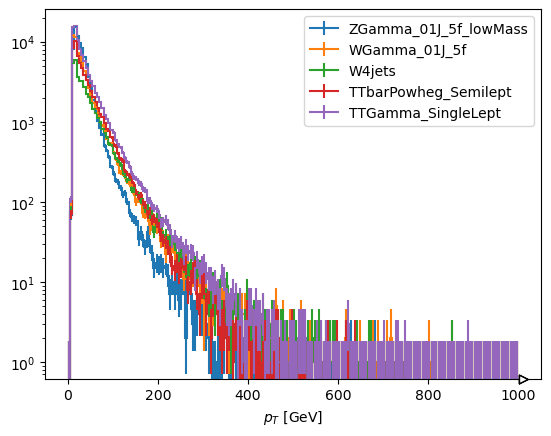

In [5]:
import hist
import matplotlib.pyplot as plt


fig, ax = plt.subplots()

for ds, histos in output.items():
    h = histos["all_photon_pt"]
    # h = histos["photon_chIso"]
    # for more complex histos you will have to reduce the dimensions with slicing
    # see https://uhi.readthedocs.io/en/latest/indexing.html for a guide
    # h = h[{"category": sum, "lepFlavor": sum, "systematic": "nominal"}]
    h.plot1d(ax=ax, label=ds)

ax.set_yscale("log")
ax.legend()

In [6]:
expected = util.load("output_Expected.coffea")

hname = "photon_chIso"
for ds, histo in expected.items():
    mine = output[ds][hname].values()
    other = expected[ds][hname].values()
    if mine.shape != other.shape:
        print(f"For dataset {ds} there is a mismatch in axes")
    elif not np.all(mine == other):
        print(f"For dataset {ds} there is a mismatch in bin yields")
    else:
        print(f"All good for {ds}")

print("Done!")

For dataset ZGamma_01J_5f_lowMass there is a mismatch in axes
For dataset WGamma_01J_5f there is a mismatch in axes
For dataset W4jets there is a mismatch in axes
For dataset TTbarPowheg_Semilept there is a mismatch in axes
For dataset TTGamma_SingleLept there is a mismatch in axes
Done!


# Accessing Arrays Interactively

Below is an example of loading a NanoAOD file interactively. This can be very useful for developing the code, and debugging any issues. Use this area to build your intuition for working with Coffea and awkward arrays!

In [7]:
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

dataset = "TTGamma_SingleLept"
fname = fileset[dataset][0]
events = NanoEventsFactory.from_root(
    {fname: "Events"},
    schemaclass=NanoAODSchema,
    entry_stop=40_000,
    metadata={"dataset": dataset},
).events()

AttributeError: 'ReadOnlyDirectory' object has no attribute 'typenames'

Once you have opened the file, you can explore its contents using the 'fields' syntax

In [ ]:
events["Photon", "charge"] = 0
events["Photon", "mass"] = 0
leadingMuon = ak.firsts(events.Muon)
leadingPhoton = ak.firsts(events.Photon)
leadingElectron = ak.firsts(events.Electron)

In [ ]:
(leadingMuon + leadingPhoton).mass

In [ ]:
mugammapairs = ak.cartesian({"mu":events.Muon, "gamma":events.Photon})
(mugammapairs.mu + mugammapairs.gamma).mass

In [ ]:
leadingMuon

In [ ]:
print(leadingMuon)

In [ ]:
type(leadingMuon)

In [ ]:
from ttgamma.scalefactors import mu_trig_err

mu_trig_err

In [ ]:
mu_trig_err(1.2, 36)

In [ ]:
events.Photon.matched_gen.fields

In [ ]:
events.GenPart.fields

There is also a docstring for each of these variables in NanoAOD, which you can access using '?':

In [ ]:
events.Jet.rawFactor?